### Topic
Diabetes prediction from data

### Model
Linear Regression

### Data
sklearn - datasets - load_diabetes

In [ ]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [ ]:
# Load Data
from sklearn.datasets import load_diabetes
data_fl = load_diabetes()

In [ ]:
# check features
data_fl["feature_names"]

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

 - Comment

 "bp" is average blood pressure.

 "s1, s2, s3, s4, s5, s6" are serum test results.

In [ ]:
# check feasure and label
data_f, data_l = data_fl["data"], data_fl["target"]

print("feasure : ", data_f[0])
print("label : ", data_l[0])

feasure :  [ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]
label :  151.0


In [ ]:
# data EDA
df = pd.DataFrame(data_f, columns=data_fl["feature_names"])
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [ ]:
# train-test data split
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = train_test_split(data_f, data_l, test_size=0.3)

In [ ]:
# check the train-test data ratio
print("train : ", len(train_data))
print("test : ", len(test_data))
print("ratio : ", len(test_data) / (len(train_data) + len(test_data)))


train :  309
test :  133
ratio :  0.3009049773755656


### Mutivariate Linear Regression

In [ ]:
# Load model and train
from sklearn.linear_model import LinearRegression
multi_regressor = LinearRegression()
multi_regressor.fit(train_data, train_target)

LinearRegression()

In [ ]:
# predict
multi_train_pred = multi_regressor.predict(train_data)
multi_test_pred = multi_regressor.predict(test_data)

In [ ]:
# Evaluation - Mean squared error
from sklearn.metrics import mean_squared_error
multi_train_mse = mean_squared_error(multi_train_pred, train_target)
multi_test_mse = mean_squared_error(multi_test_pred, test_target)
print(f"Multi Regression Train MSE is {multi_train_mse:.4f}")
print(f"Multi Regression Test MSE is {multi_test_mse:.4f}")

Multi Regression Train MSE is 2924.0464
Multi Regression Test MSE is 2821.7510


### Regularization - Ridge and Lasso

In [ ]:
# Ridge
from sklearn.linear_model import Ridge
ridge_regressor = Ridge()
ridge_regressor.fit(train_data, train_target)
ridge_train_pred = ridge_regressor.predict(train_data)
ridge_test_pred = ridge_regressor.predict(test_data)
ridge_train_mse = mean_squared_error(ridge_train_pred, train_target)
ridge_test_mse = mean_squared_error(ridge_test_pred, test_target)
print(f"Ridge Regression Train MSE is {ridge_train_mse:.4f}")
print(f"Ridge Regression Test MSE is {ridge_test_mse:.4f}")

Ridge Regression Train MSE is 3514.8611
Ridge Regression Test MSE is 3112.9664


In [ ]:
# Lasso
from sklearn.linear_model import Lasso
lasso_regressor = Lasso()
lasso_regressor.fit(train_data, train_target)
lasso_train_pred = lasso_regressor.predict(train_data)
lasso_test_pred = lasso_regressor.predict(test_data)
lasso_train_mse = mean_squared_error(lasso_train_pred, train_target)
lasso_test_mse = mean_squared_error(lasso_test_pred, test_target)
print(f"LASSO Regression Train MSE is {lasso_train_mse:.4f}")
print(f"LASSO Regression Test MSE is {lasso_test_mse:.4f}")

LASSO Regression Train MSE is 3958.2819
LASSO Regression Test MSE is 3444.6708


### Summary





In [ ]:
print(f"Multi Regression Test MSE is {multi_test_mse:.4f}")
print(f"Ridge Regression Test MSE is {ridge_test_mse:.4f}")
print(f"LASSO Regression Test MSE is {lasso_test_mse:.4f}")

Multi Regression Test MSE is 2821.7510
Ridge Regression Test MSE is 3112.9664
LASSO Regression Test MSE is 3444.6708


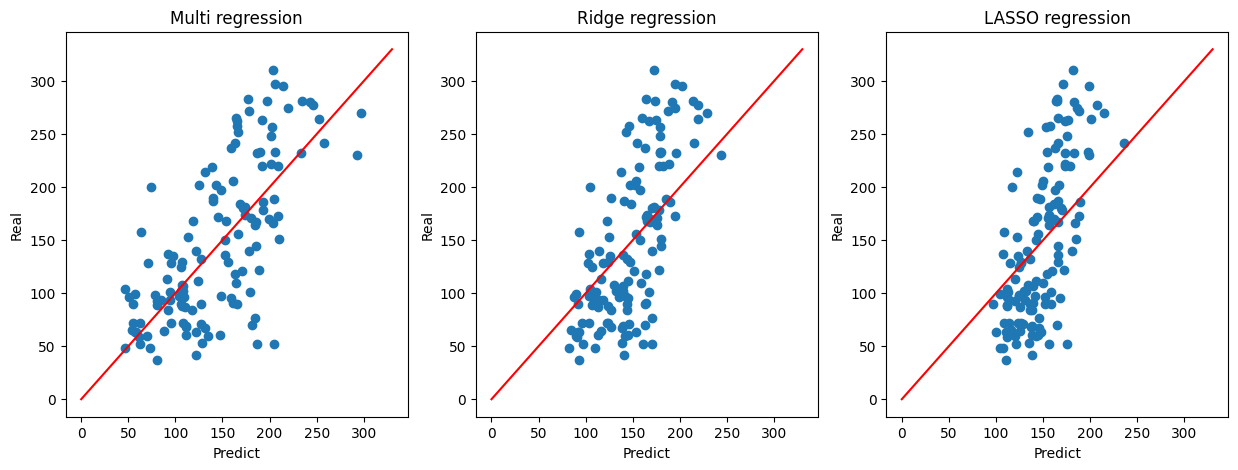

In [ ]:
ig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
preds = [
    ("Multi regression", multi_test_pred),
    ("Ridge regression", ridge_test_pred),
    ("LASSO regression", lasso_test_pred),
]

for idx, (name, test_pred) in enumerate(preds):
    ax = axes[idx]
    ax.scatter(test_pred, test_target)
    ax.plot(np.linspace(0, 330, 100), np.linspace(0, 330, 100), color="red")
    ax.set_xlabel("Predict")
    ax.set_ylabel("Real")
    ax.set_title(name)